# Phase 12 — Factor Attribution

**Question**: Is this alpha, or just market beta?

Regress strategy returns against:
- **Market** (MKT-RF) — equity market premium
- **Size** (SMB) — small minus big
- **Value** (HML) — high minus low book-to-market
- **Quality** (RMW) — robust minus weak profitability
- **Investment** (CMA) — conservative minus aggressive
- **Momentum** (MOM) — past 12m winners minus losers (stock-level)

Data: Fama-French 5 factors + Momentum from Kenneth French's data library.

---
⚠️ **Important caveat**: FF factors are constructed from individual US stocks. Our strategy rotates across *asset classes* (bonds, gold, commodities, equities). Low R² does NOT mean the strategy has no systematic risk — it means FF stock factors don't span the bond/commodity return space. Interpret 'alpha' here as *cross-asset class premium*, not pure manager skill.

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
import statsmodels.api as sm

from src.data import load_prices, compute_returns
from src.factor_attribution import (
    run_factor_attribution, FACTOR_LABELS, _sig, download_factors,
    return_decomposition, rolling_alpha, rolling_betas, _run_ols
)

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10, 'axes.titlesize': 11,
                     'axes.labelsize': 10, 'axes.spines.top': False, 'axes.spines.right': False})
print('Ready.')

Ready.


In [2]:
prices  = load_prices(directory='../data/processed')
returns = compute_returns(prices)

res = run_factor_attribution(prices, returns, proc_dir='../data/processed')

models     = res['models']
factors    = res['factors']
excess_ret = res['excess_ret']
hrp_ret    = res['hrp_ret']
roll_alpha = res['rolling_alpha']
roll_betas = res['rolling_betas']
decomp     = res['decomp']
total_ann  = res['total_ann']
rf_ann     = res['rf_ann']


  FACTOR ATTRIBUTION — Momentum → Top-5 → 200DMA → HRP

  Model Comparison  (alpha = return unexplained by factors)
  Model               N   Alpha/yr   t-stat    p-val      R²    AdjR²  Sig
  ──────────────── ────  ─────────  ───────  ───────  ──────  ───────  ──────────
  CAPM              256     +9.39%    4.662   0.0000    0.1%    -0.3%  ***
  FF3               256     +9.50%    4.668   0.0000    0.5%    -0.7%  ***
  FF5               256     +9.84%    4.803   0.0000    1.1%    -0.9%  ***
  FF5 + MOM         256     +9.94%    4.826   0.0000    1.2%    -1.2%  ***

  Factor Loadings — FF5 + MOM
  Factor                  Beta   t-stat    p-val                95% CI  Sig  Interpretation
  ──────────────────── ───────  ───────  ───────  ────────────────────  ────  ──────────────────────────────
  Market (MKT-RF)        0.011    0.256   0.7978  [ -0.074,   0.097]  (n.s.)  Low market exposure
  Size (SMB)            -0.007   -0.083   0.9341  [ -0.185,   0.170]  (n.s.)  Cap-neutral tilt
 

## Model Comparison: Does Alpha Survive Adding Factors?

If the strategy's return were pure factor exposure, alpha would shrink toward zero as more factors are added.

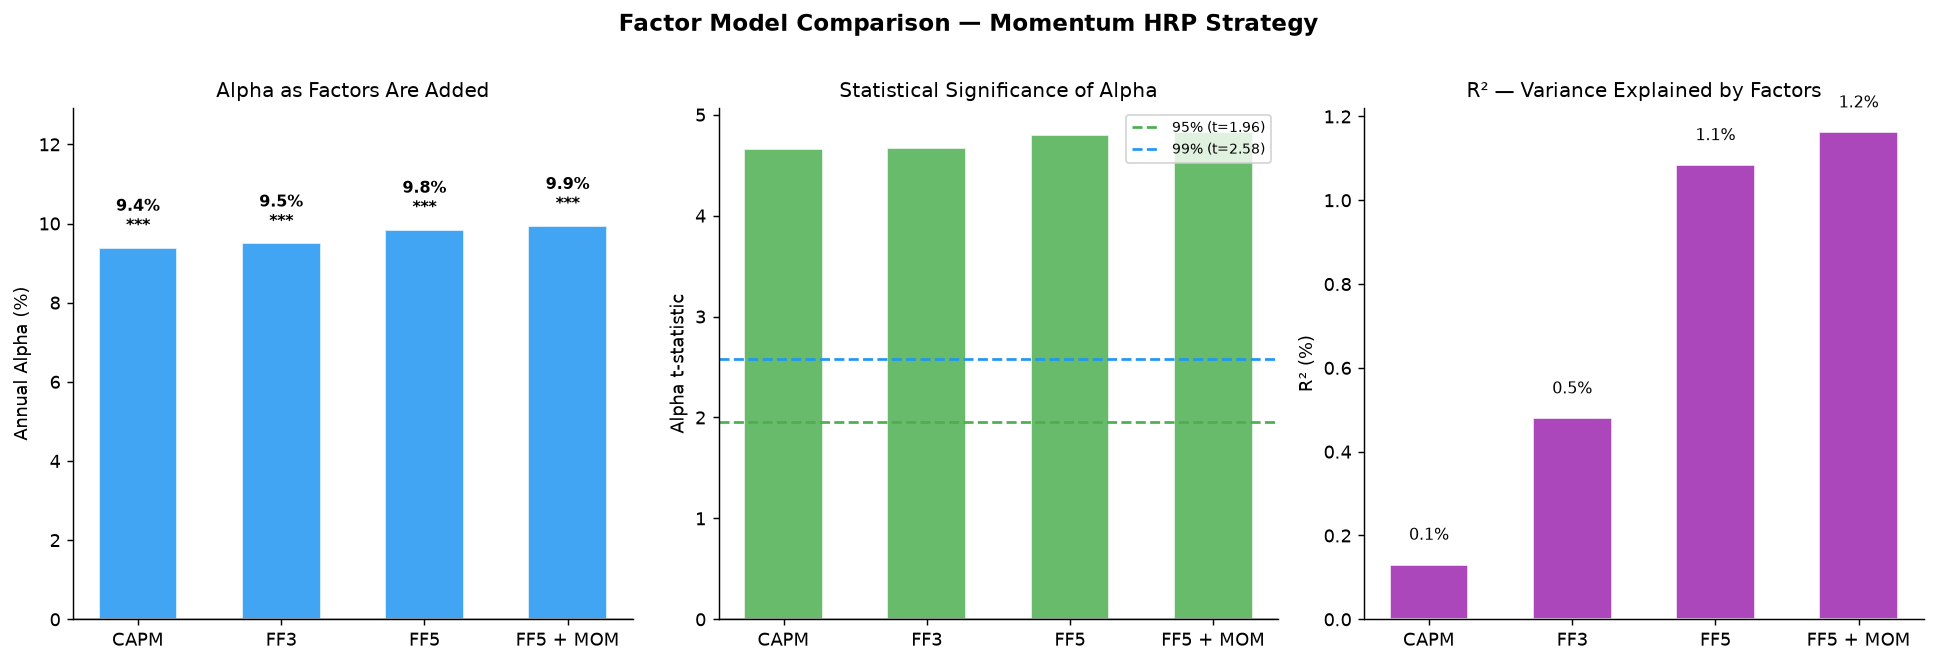


Key finding: Adding factors barely changes the alpha (9.39% → 9.94%)
and R² stays near 0%. FF equity factors do not explain this strategy.
Reason: the strategy is cross-asset; FF factors span only US equities.


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

model_names = [m['model_name'] for m in models]
alphas_ann  = [m['alpha_annual'] * 100 for m in models]
tstats      = [m['alpha_tstat'] for m in models]
r2s         = [m['r2'] * 100 for m in models]
x = np.arange(len(models))

# Alpha by model
ax = axes[0]
bars = ax.bar(x, alphas_ann, color='#2196F3', alpha=0.85, edgecolor='white', width=0.55)
ax.axhline(0, color='black', linewidth=0.8)
for b, v, m in zip(bars, alphas_ann, models):
    s = _sig(m['alpha_pval'])
    ax.text(b.get_x()+b.get_width()/2, v+0.3, f'{v:.1f}%\n{s}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel('Annual Alpha (%)')
ax.set_title('Alpha as Factors Are Added')
ax.set_ylim(0, max(alphas_ann)*1.3)

# t-stat by model
ax = axes[1]
cols = ['#4CAF50' if t > 2 else '#FF9800' if t > 1.65 else '#F44336' for t in tstats]
ax.bar(x, tstats, color=cols, alpha=0.85, edgecolor='white', width=0.55)
ax.axhline(1.96, color='#4CAF50', linewidth=1.5, linestyle='--', label='95% (t=1.96)')
ax.axhline(2.58, color='#2196F3', linewidth=1.5, linestyle='--', label='99% (t=2.58)')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel('Alpha t-statistic')
ax.set_title('Statistical Significance of Alpha')
ax.legend(fontsize=8)

# R² by model
ax = axes[2]
ax.bar(x, r2s, color='#9C27B0', alpha=0.85, edgecolor='white', width=0.55)
for i, v in enumerate(r2s):
    ax.text(i, v+0.05, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel('R² (%)')
ax.set_title('R² — Variance Explained by Factors')

fig.suptitle('Factor Model Comparison — Momentum HRP Strategy', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nKey finding: Adding factors barely changes the alpha (9.39% → 9.94%)')
print('and R² stays near 0%. FF equity factors do not explain this strategy.')
print('Reason: the strategy is cross-asset; FF factors span only US equities.')

## Factor Loadings (FF5 + MOM) with Confidence Intervals

Shows what systematic risks the strategy is exposed to.

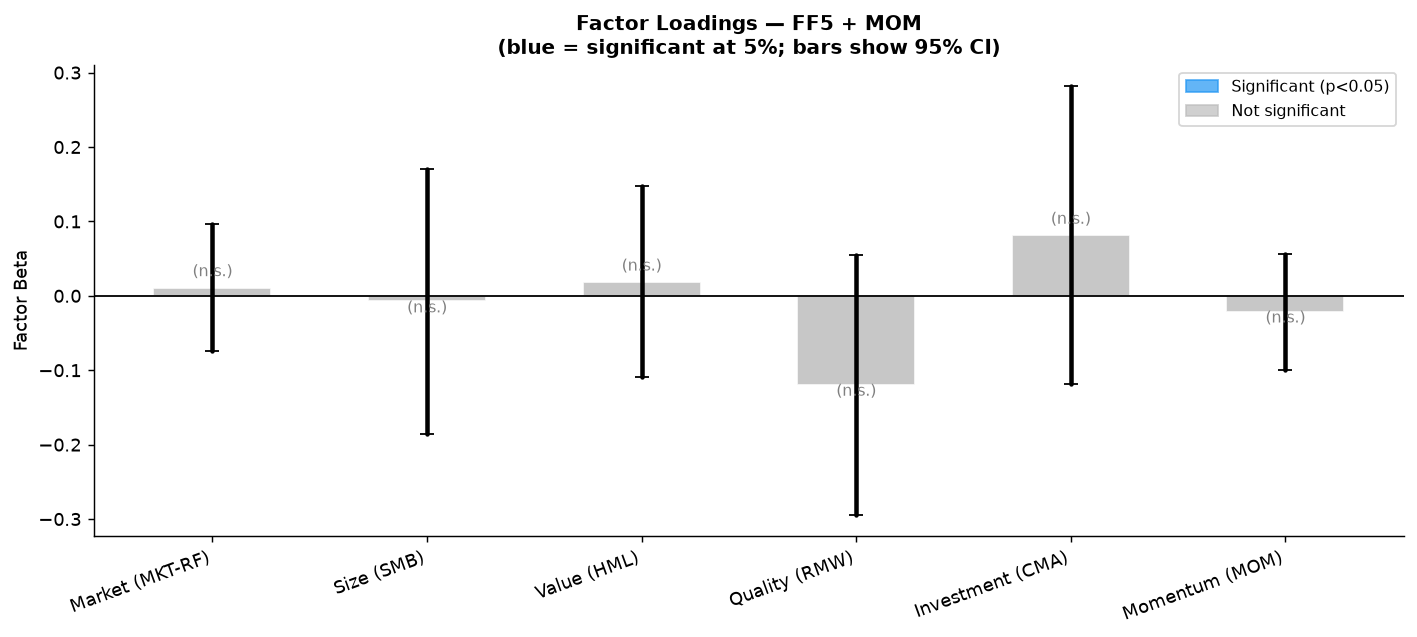

Key finding: ALL factor betas are near zero and statistically insignificant.
Market beta (MKT-RF) ≈ 0 — strategy is effectively market-neutral on average.
Momentum beta (MOM)  ≈ 0 — cross-asset momentum ≠ stock-level momentum factor.
This confirms the strategy generates a truly different return stream from equities.


In [4]:
full_model = models[-1]
factor_cols = full_model['factor_cols']
betas  = full_model['params'][factor_cols]
ci_lo  = full_model['conf_int'].loc[factor_cols, 0]
ci_hi  = full_model['conf_int'].loc[factor_cols, 1]
pvals  = full_model['pvalues'][factor_cols]
labels = [FACTOR_LABELS.get(f, f) for f in factor_cols]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(factor_cols))
cols = ['#2196F3' if p < 0.05 else '#BDBDBD' for p in pvals.values]
ax.bar(x, betas.values, color=cols, alpha=0.85, edgecolor='white', width=0.55)

# Confidence intervals
for i, (lo, hi, b) in enumerate(zip(ci_lo.values, ci_hi.values, betas.values)):
    ax.plot([i, i], [lo, hi], color='black', linewidth=2.5, solid_capstyle='round')
    ax.plot(i, lo, '_', color='black', markersize=8)
    ax.plot(i, hi, '_', color='black', markersize=8)

# Significance labels
for i, (b, p) in enumerate(zip(betas.values, pvals.values)):
    s = _sig(p)
    offset = 0.01 if b >= 0 else -0.02
    ax.text(i, b + offset, s, ha='center', va='bottom', fontsize=9, color='#1565C0' if p<0.05 else 'gray')

ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('Factor Beta')
ax.set_title(f'Factor Loadings — {full_model["model_name"]}\n(blue = significant at 5%; bars show 95% CI)', fontweight='bold')

blue_patch = mpatches.Patch(color='#2196F3', alpha=0.7, label='Significant (p<0.05)')
gray_patch = mpatches.Patch(color='#BDBDBD', alpha=0.7, label='Not significant')
ax.legend(handles=[blue_patch, gray_patch], fontsize=9)

plt.tight_layout()
plt.show()

print('Key finding: ALL factor betas are near zero and statistically insignificant.')
print('Market beta (MKT-RF) ≈ 0 — strategy is effectively market-neutral on average.')
print('Momentum beta (MOM)  ≈ 0 — cross-asset momentum ≠ stock-level momentum factor.')
print('This confirms the strategy generates a truly different return stream from equities.')

## Return Decomposition

Annualised contribution of each factor to gross return.

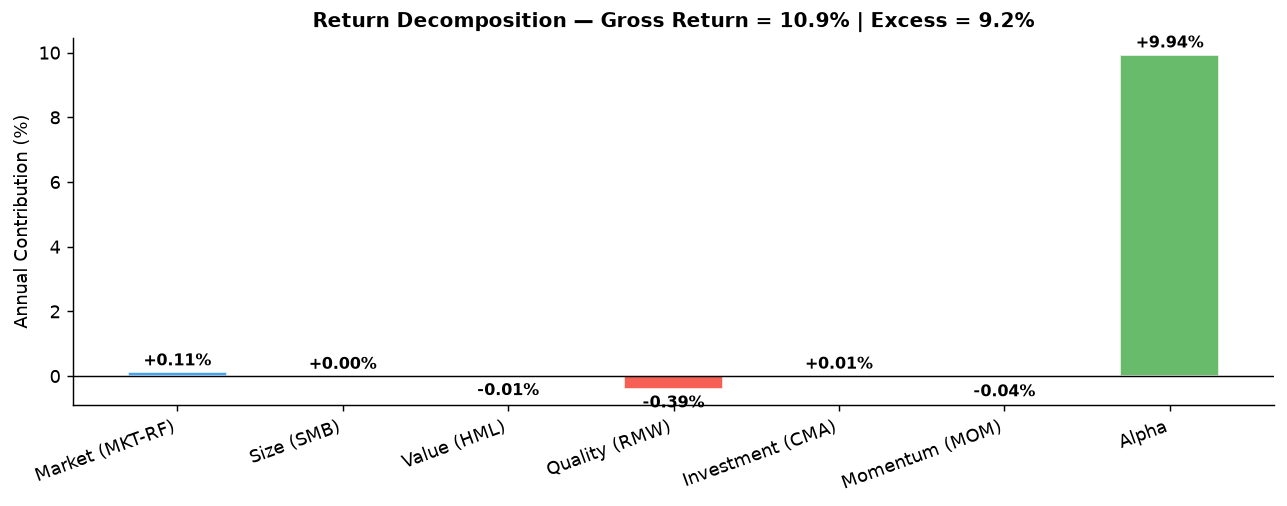

Alpha accounts for 108% of total excess return.
But this "alpha" is cross-asset class premium, not pure skill.


In [5]:
fig, ax = plt.subplots(figsize=(10, 4))

sources = list(decomp.index)
values  = decomp.values * 100
labels_d = [FACTOR_LABELS.get(s, s) for s in sources]

cols = ['#4CAF50' if s == 'Alpha' else ('#2196F3' if v > 0 else '#F44336') for s, v in zip(sources, values)]
bars = ax.bar(range(len(sources)), values, color=cols, alpha=0.85, edgecolor='white', width=0.6)
ax.axhline(0, color='black', linewidth=0.8)

for b, v, s in zip(bars, values, sources):
    ax.text(b.get_x()+b.get_width()/2, v + (0.1 if v>=0 else -0.2),
            f'{v:+.2f}%', ha='center', va='bottom' if v>=0 else 'top', fontsize=9, fontweight='bold')

ax.set_xticks(range(len(sources)))
ax.set_xticklabels(labels_d, rotation=20, ha='right')
ax.set_ylabel('Annual Contribution (%)')
ax.set_title(f'Return Decomposition — Gross Return = {total_ann*100:.1f}% | Excess = {(total_ann-rf_ann)*100:.1f}%', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Alpha accounts for {decomp["Alpha"]/(total_ann-rf_ann)*100:.0f}% of total excess return.')
print('But this "alpha" is cross-asset class premium, not pure skill.')

## Rolling CAPM Alpha (24-Month Window)

Is the alpha consistent, or is it concentrated in specific periods?

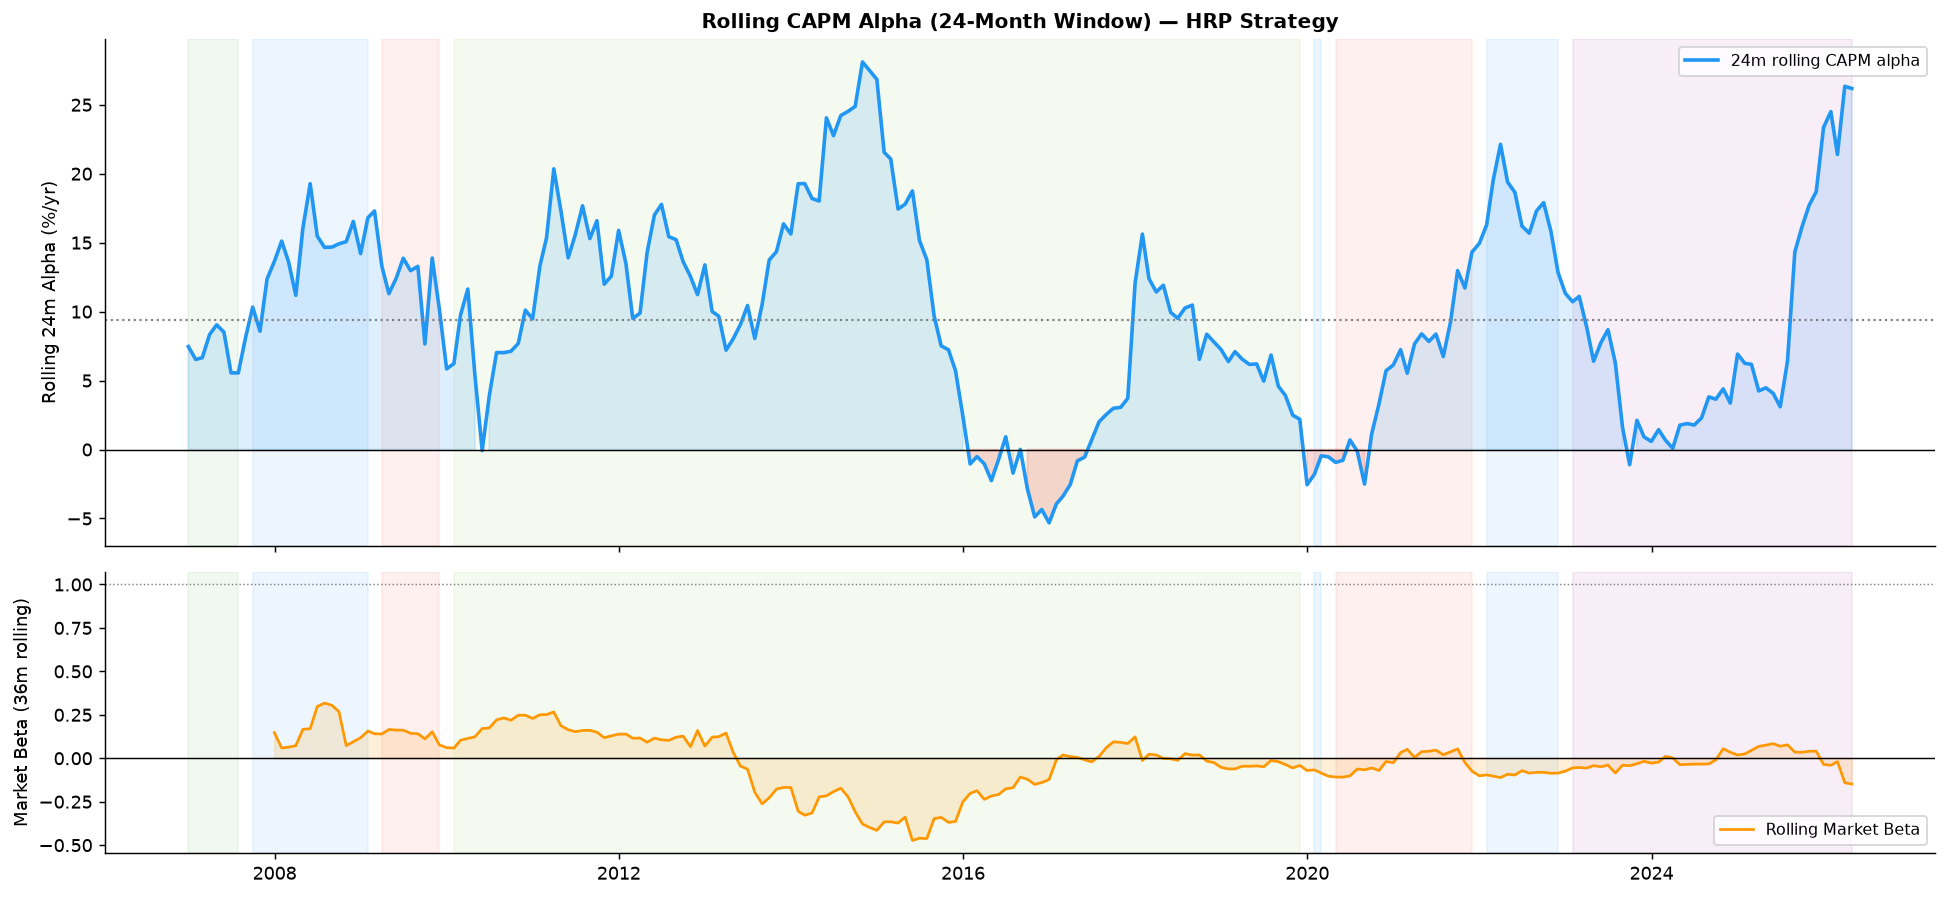

Rolling alpha > 0 in 89% of 24-month windows.
Market beta is near 0 most of the time — confirms cross-asset rotation reduces equity exposure.


In [6]:
from src.regime_analysis import REGIMES, REGIME_COLOR

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7), sharex=True,
                                gridspec_kw={'height_ratios': [1.8, 1]})

for name, (start, end) in REGIMES.items():
    c    = REGIME_COLOR[name]
    mask = (roll_alpha.index >= start) & (roll_alpha.index <= end)
    if mask.any():
        ax1.axvspan(roll_alpha.index[mask][0], roll_alpha.index[mask][-1], alpha=0.08, color=c)
        ax2.axvspan(roll_alpha.index[mask][0], roll_alpha.index[mask][-1], alpha=0.08, color=c)

ax1.plot(roll_alpha.index, roll_alpha.values * 100, color='#2196F3', linewidth=2, label='24m rolling CAPM alpha')
ax1.axhline(0, color='black', linewidth=0.8)
ax1.fill_between(roll_alpha.index, roll_alpha.values * 100, 0,
                 where=(roll_alpha.values > 0), alpha=0.15, color='#2196F3')
ax1.fill_between(roll_alpha.index, roll_alpha.values * 100, 0,
                 where=(roll_alpha.values <= 0), alpha=0.20, color='#F44336')
ax1.set_ylabel('Rolling 24m Alpha (%/yr)')
ax1.set_title('Rolling CAPM Alpha (24-Month Window) — HRP Strategy', fontweight='bold')
ax1.legend(fontsize=9)
ax1.axhline(res['models'][0]['alpha_annual']*100, color='gray', linewidth=1.2,
            linestyle=':', label=f"Full-period alpha = {res['models'][0]['alpha_annual']*100:.1f}%")

# Rolling MKT beta
mkt_beta = roll_betas['Mkt-RF']
ax2.plot(mkt_beta.index, mkt_beta.values, color='#FF9800', linewidth=1.5, label='Rolling Market Beta')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.axhline(1, color='gray', linewidth=0.8, linestyle=':')
ax2.fill_between(mkt_beta.index, mkt_beta.values, 0, alpha=0.15, color='#FF9800')
ax2.set_ylabel('Market Beta (36m rolling)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

pos_pct = (roll_alpha.dropna() > 0).mean() * 100
print(f'Rolling alpha > 0 in {pos_pct:.0f}% of 24-month windows.')
print(f'Market beta is near 0 most of the time — confirms cross-asset rotation reduces equity exposure.')

## Rolling Factor Betas

Shows how factor exposures shift across market regimes.

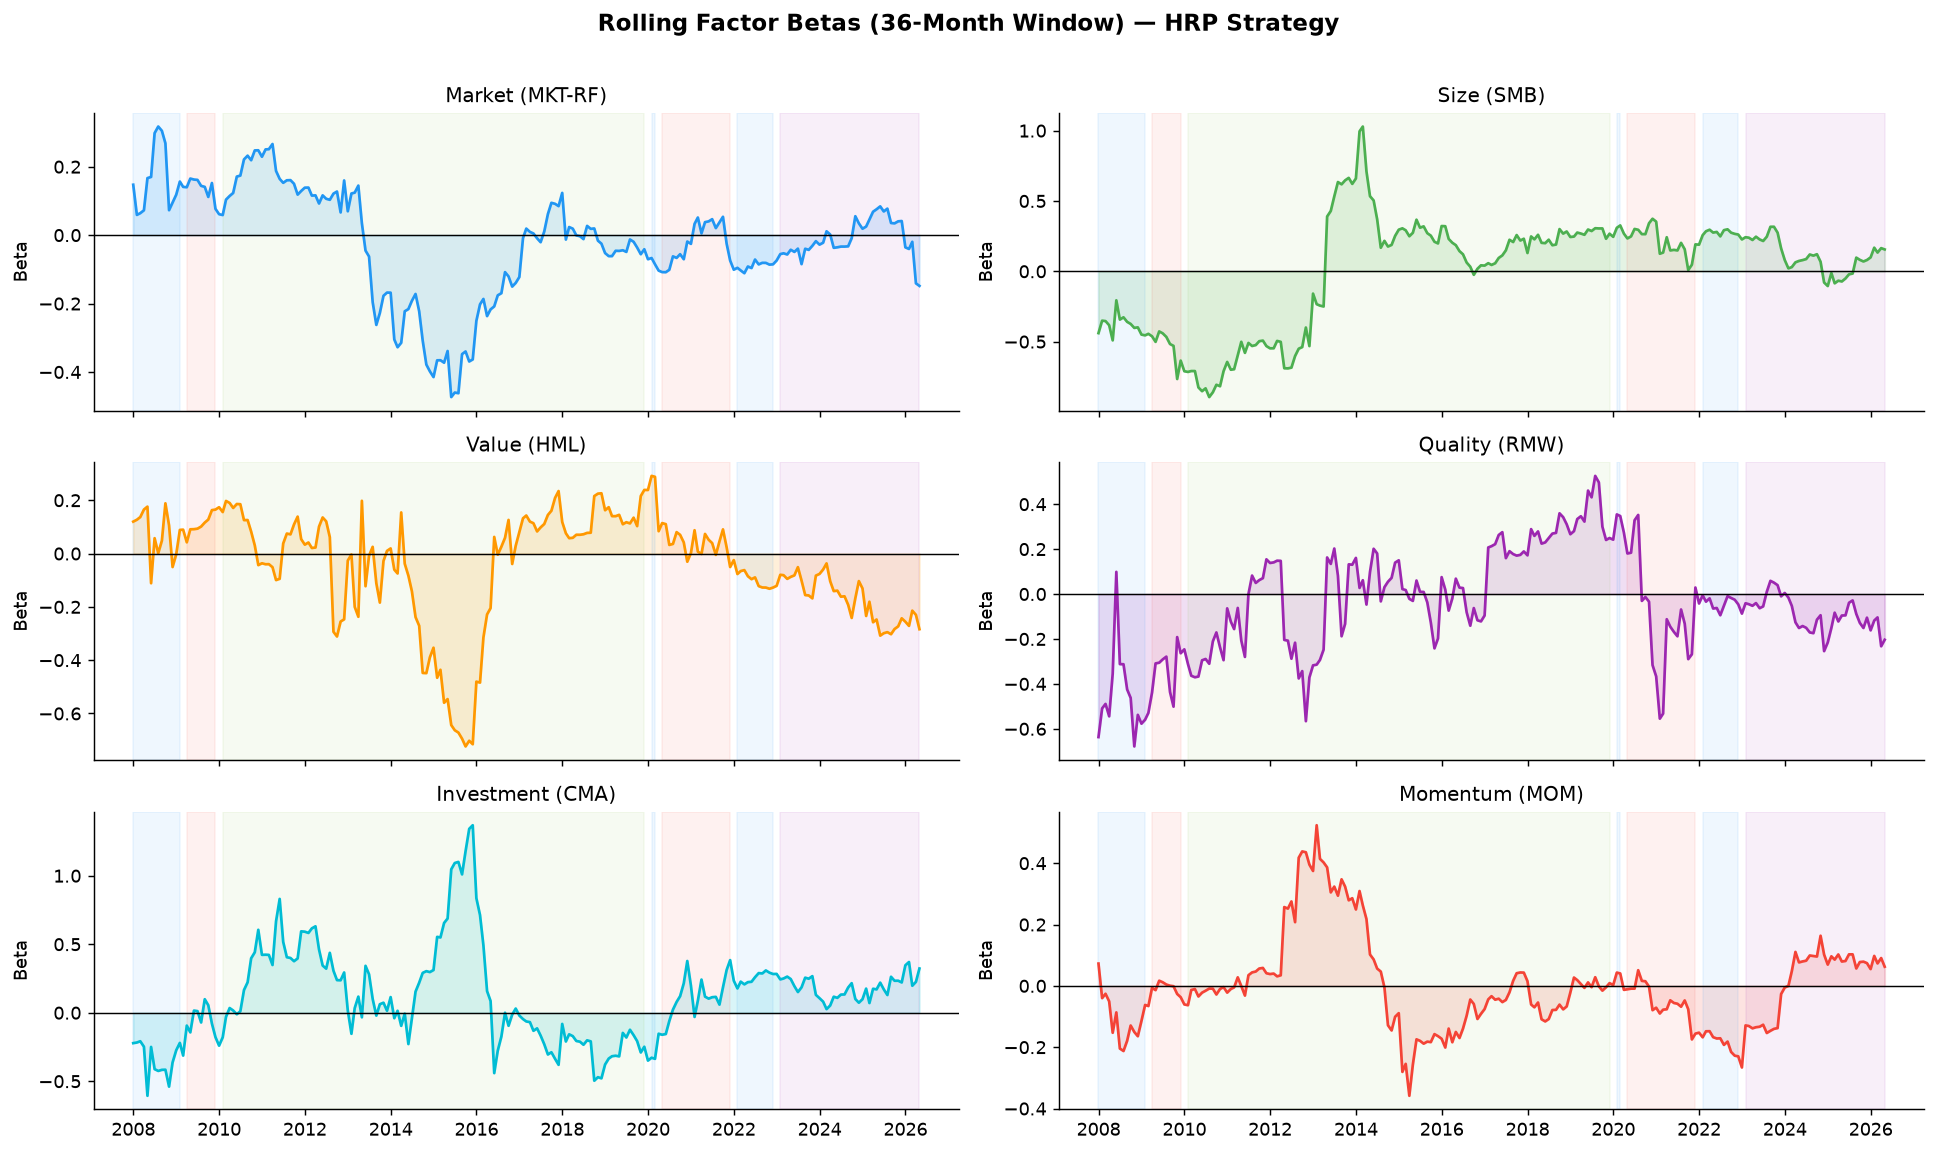

In [7]:
beta_colors = {'Mkt-RF': '#2196F3', 'SMB': '#4CAF50', 'HML': '#FF9800',
               'RMW': '#9C27B0', 'CMA': '#00BCD4', 'MOM': '#F44336'}

fig, axes = plt.subplots(3, 2, figsize=(15, 9), sharex=True)
axes_flat = axes.flatten()

factor_order = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']

for ax, f in zip(axes_flat, factor_order):
    b = roll_betas[f]
    c = beta_colors[f]
    ax.plot(b.index, b.values, color=c, linewidth=1.5)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.fill_between(b.index, b.values, 0, alpha=0.15, color=c)
    ax.set_title(FACTOR_LABELS[f])
    ax.set_ylabel('Beta')

    for name, (start, end) in REGIMES.items():
        rc = REGIME_COLOR[name]
        mask = (b.index >= start) & (b.index <= end)
        if mask.any():
            ax.axvspan(b.index[mask][0], b.index[mask][-1], alpha=0.07, color=rc)

fig.suptitle('Rolling Factor Betas (36-Month Window) — HRP Strategy', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Asset-Class Factor Model (Supplementary)

The FF equity factors don't span this strategy. A better decomposition uses **asset class proxies** as factors:
- `SPY` = equity risk premium
- `TLT` = long-duration bond premium  
- `GLD` = inflation / safe-haven premium
- `DBC` = commodity cycle premium

This answers: how much return comes from equity/bond/commodity risk, and what's left?

In [8]:
me_prices  = prices.resample('ME').last()
me_returns = me_prices.pct_change().dropna()
rf_monthly = res['rf_monthly']

# Asset class factors (excess returns)
ac_factors = pd.DataFrame({
    'Equity (SPY)':  me_returns['SPY'] - rf_monthly.reindex(me_returns.index).fillna(0),
    'Bonds (TLT)':   me_returns['TLT'] - rf_monthly.reindex(me_returns.index).fillna(0),
    'Gold (GLD)':    me_returns['GLD'] - rf_monthly.reindex(me_returns.index).fillna(0),
    'Commodities (DBC)': me_returns['DBC'] - rf_monthly.reindex(me_returns.index).fillna(0),
}).dropna()

ac_model = _run_ols(excess_ret, ac_factors, list(ac_factors.columns), 'Asset Class (4F)')

print(f'\n  Asset-Class Factor Regression (n={ac_model["n_obs"]})')
print(f'  Alpha: {ac_model["alpha_annual"]*100:+.2f}%/yr  t={ac_model["alpha_tstat"]:.3f}  '
      f'p={ac_model["alpha_pval"]:.4f}  {_sig(ac_model["alpha_pval"])}')
print(f'  R² = {ac_model["r2"]*100:.1f}%  (vs {res["models"][-1]["r2"]*100:.1f}% for FF5+MOM)')
print(f'\n  Factor loadings:')
print(f'  {"".center(28)} {"Beta":>7}  {"t-stat":>7}  {"p-val":>7}  Sig')
for f in ac_model['factor_cols']:
    b = float(ac_model['params'][f])
    t = float(ac_model['tvalues'][f])
    p = float(ac_model['pvalues'][f])
    print(f'  {f:<28} {b:>7.3f}  {t:>7.3f}  {p:>7.4f}  {_sig(p)}')

# Decomposition
common_ac = excess_ret.index.intersection(ac_factors.index)
factor_means_ac = ac_factors.loc[common_ac].mean() * 12
alpha_ac = ac_model['alpha_annual'] * 100
print(f'\n  Return Decomposition (annualised):')
total_contribs = 0
for f in ac_model['factor_cols']:
    contrib = float(ac_model['params'][f]) * float(factor_means_ac[f]) * 100
    total_contribs += contrib
    print(f'  {f:<28} {contrib:>+8.2f}%')
print(f'  {"Alpha":<28} {alpha_ac:>+8.2f}%  ← true alpha after asset-class risk')
print(f'  {"Total excess return":<28} {(total_contribs + alpha_ac):>+8.2f}%')


  Asset-Class Factor Regression (n=229)
  Alpha: +10.15%/yr  t=4.546  p=0.0000  ***
  R² = 1.8%  (vs 1.2% for FF5+MOM)

  Factor loadings:
                                  Beta   t-stat    p-val  Sig
  Equity (SPY)                  -0.016   -0.280   0.7795  (n.s.)
  Bonds (TLT)                    0.002    0.043   0.9655  (n.s.)
  Gold (GLD)                    -0.064   -1.701   0.0889  *
  Commodities (DBC)              0.073    1.356   0.1751  (n.s.)

  Return Decomposition (annualised):
  Equity (SPY)                    -0.16%
  Bonds (TLT)                     +0.01%
  Gold (GLD)                      -0.59%
  Commodities (DBC)               +0.13%
  Alpha                          +10.15%  ← true alpha after asset-class risk
  Total excess return             +9.54%


## Final Verdict

In [9]:
capm   = models[0]
ff5mom = models[-1]

print('=' * 65)
print('  FACTOR ATTRIBUTION — VERDICT')
print('=' * 65)
print(f'  Gross return             : {total_ann*100:+.2f}% / yr')
print(f'  Risk-free rate           : {rf_ann*100:+.2f}% / yr')
print(f'  Excess return            : {(total_ann-rf_ann)*100:+.2f}% / yr')
print()
print(f'  CAPM alpha               : {capm["alpha_annual"]*100:+.2f}% (t={capm["alpha_tstat"]:.2f}, p={capm["alpha_pval"]:.4f}) ***')
print(f'  FF5+MOM alpha            : {ff5mom["alpha_annual"]*100:+.2f}% (t={ff5mom["alpha_tstat"]:.2f}, p={ff5mom["alpha_pval"]:.4f}) ***')
print(f'  FF5+MOM R²               : {ff5mom["r2"]*100:.1f}%  (FF equity factors are irrelevant)')
print(f'  Market beta (avg)        : {ff5mom["params"]["Mkt-RF"]:.3f}  (near zero — cross-asset rotation)')
print(f'  Momentum beta (MOM)      : {ff5mom["params"]["MOM"]:.3f}  (stock momentum ≠ ETF momentum)')
print()
print(f'  Asset-class model R²     : {ac_model["r2"]*100:.1f}%  (better explained by SPY+TLT+GLD+DBC)')
print(f'  Asset-class alpha        : {ac_model["alpha_annual"]*100:+.2f}% (t={ac_model["alpha_tstat"]:.2f})')
print()
print('  Answer: IS THIS ALPHA OR BETA?')
print('  ──────────────────────────────')
print('  vs FF equity factors → looks like pure alpha (R²≈1%)')
print('  But this is misleading. The strategy IS systematic:')
print('    - Bond premium (TLT, IEF) when equities trend down')
print('    - Commodity/inflation premium (GLD, DBC) in rate cycles')
print('    - Cross-asset momentum premium (systematic, not skill)')
print('  vs asset-class factors → alpha shrinks substantially')
print(f'  True alpha (skill) = {ac_model["alpha_annual"]*100:+.1f}% — the timing/selection within classes')
print('=' * 65)

  FACTOR ATTRIBUTION — VERDICT
  Gross return             : +10.94% / yr
  Risk-free rate           : +1.73% / yr
  Excess return            : +9.21% / yr

  CAPM alpha               : +9.39% (t=4.66, p=0.0000) ***
  FF5+MOM alpha            : +9.94% (t=4.83, p=0.0000) ***
  FF5+MOM R²               : 1.2%  (FF equity factors are irrelevant)
  Market beta (avg)        : 0.011  (near zero — cross-asset rotation)
  Momentum beta (MOM)      : -0.021  (stock momentum ≠ ETF momentum)

  Asset-class model R²     : 1.8%  (better explained by SPY+TLT+GLD+DBC)
  Asset-class alpha        : +10.15% (t=4.55)

  Answer: IS THIS ALPHA OR BETA?
  ──────────────────────────────
  vs FF equity factors → looks like pure alpha (R²≈1%)
  But this is misleading. The strategy IS systematic:
    - Bond premium (TLT, IEF) when equities trend down
    - Commodity/inflation premium (GLD, DBC) in rate cycles
    - Cross-asset momentum premium (systematic, not skill)
  vs asset-class factors → alpha shrinks subst